In [1]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn import preprocessing

### Functions for Calculation Centralities

In [2]:
# Weighted Closeness Centrality
def weighted_closeness(G):
    nodes = list(G.nodes())
    closeness = []
    for i in range(0, len(nodes)):
        close = []
        dist_ij = 0
        for j in range(0, len(nodes)):
            if(nodes[i] == nodes[j]):
                    continue
            else:
                wt , s_path = nx.bidirectional_dijkstra(G, source=nodes[i], target=nodes[j], weight='weight')
                dist_ij = dist_ij + wt
        closeness_i = 1 / dist_ij
        close.append(nodes[i])
        close.append(closeness_i)
        closeness.append(close)
    return closeness

# Weighted Betweenness Centrality
def weighted_betweenness(G):
    nodes = list(G.nodes())
    betweenness = []
    for n in range(0, len(nodes)):
        bett = []
        dist_n = 0
        dist_v = 0
        for s in range(0, len(nodes)):
            for t in range(s+1, len(nodes)):
                if(nodes[n] == nodes[s] or nodes[n] == nodes[t] or nodes[s] == nodes[t]):
                    continue
                else:
                    wt , s_path = nx.bidirectional_dijkstra(G, source=nodes[s], target=nodes[t], weight='weight')
                    if(nodes[n] in s_path):
                        dist_n = dist_n + wt
                    dist_v = dist_v + wt
        betweenness_n = dist_n / dist_v
        bett.append(nodes[n])
        bett.append(betweenness_n)
        betweenness.append(bett)
    return betweenness

# Weighted Edge Contribution Factor
def weighted_ECF(G, W):
    nodes = list(G.nodes())
    ecf = []
    for i in range(0, len(nodes)):
        ecf_ = []
        w_ij = 0
        w_jk = 0
        neighbours_i = list(G.neighbors(nodes[i]))
        for n in range(0, len(neighbours_i)):
            w_ = G.get_edge_data(nodes[i], neighbours_i[n])
            val = w_['weight']
            w_ij = w_ij + val
        nbunch = neighbours_i
        common_neighbours = G.edges(nbunch, data=True)
        common_neighbours = list(common_neighbours)
        for j in range(0, len(common_neighbours)):
            if((common_neighbours[j][0] == nodes[i]) or (common_neighbours[j][1] == nodes[i])):
                continue
            elif(((common_neighbours[j][0] in neighbours_i) == False) or ((common_neighbours[j][1] in neighbours_i) == False )):
                continue
            else:
                w_ = G.get_edge_data(common_neighbours[j][0], common_neighbours[j][1])
                val = w_['weight']
                w_jk = w_jk + val            
            
        w_ecf = (w_ij + w_jk) / W
        ecf_.append(nodes[i])
        ecf_.append(w_ecf)
        ecf.append(ecf_)
    return ecf

def degree(G,W):
    nodes = list(G.nodes())
    w_degree = []
    for i in range(0, len(nodes)):
        deg = []
        nd = nodes[i]
        m_dg = modi_deg(G,nd,W)
        deg.append(nd)
        deg.append(m_dg)
        w_degree.append(deg)
    return w_degree

# New One
def modi_deg(G,i,W_):
    d_i = G.degree(i, weight='weight')
    m_deg = (d_i/W_)/2
    return m_deg

def edge_weighted(G,i):
    all_edges = []
    nbr_i = list(G.neighbors(i))
    for n in range(0,len(nbr_i)):
        j = nbr_i[n]
        adjacent_edges_j = list(G.edges(j))
        all_edges.append(adjacent_edges_j)
    
    all_edges = list(all_edges)
    al_edges = []
    for e in range(0,len(all_edges)):
        al_edges = al_edges + all_edges[e]
    
    rmv_edges = []
    for e_ in range(0, len(al_edges)):
        ed = al_edges[e_]
        if((ed[0] == i) or (ed[1] == i)):
            rmv_edges.append(ed)

    for ed in range(0, len(rmv_edges)):
        rmv_e = rmv_edges[ed]
        al_edges.remove(rmv_e)
        
    if(len(al_edges) == 0):
        return 0
    else:
        refined_edges = list({*map(tuple, map(sorted, al_edges))})
    
        ew_i = 0
        for a in range(0,len(refined_edges)):
            ii = refined_edges[a][0]
            jj = refined_edges[a][1]
            w_jk = G.get_edge_data(ii, jj)
            val = w_jk['weight']
            ew_i = ew_i + val
    
        return ew_i

def weight_of_a_node(G,i,W_1):
    m_deg = modi_deg(G,i,W_1)
    deg_i = G.degree(i, weight='weight')
    edge_wt = edge_weighted(G,i)
    value = (deg_i + edge_wt)/W_1
    weight_value = value * m_deg
    return weight_value


def weighted_cness(G, W):
    nodes = list(G.nodes())
    w_closeness = []
    for i in range(0, len(nodes)):
        closeness = []
        nd = nodes[i]
        weight = weight_of_a_node(G,nd,W)
        closeness.append(nd)
        closeness.append(weight)
        w_closeness.append(closeness)
    return w_closeness
# End of New One


# Total Edge Weight of a Graph
def total_weight_of_G(G):
    edge_weights = list(G.edges.data('weight'))
    W_ = 0
    for e in range(len(edge_weights)):
        w = edge_weights[e][2]
        W_ += w
    return W_


def convert_to_list_value(lst,index):
    l = []
    for i in range(0, len(lst)):
        val = lst[i][index]
        l.append(val)
    return l

### Loading Dataset and Create the Network and its Visualization

### s_m_1

Name: 
Type: Graph
Number of nodes: 18
Number of edges: 21
Average degree:   2.3333


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


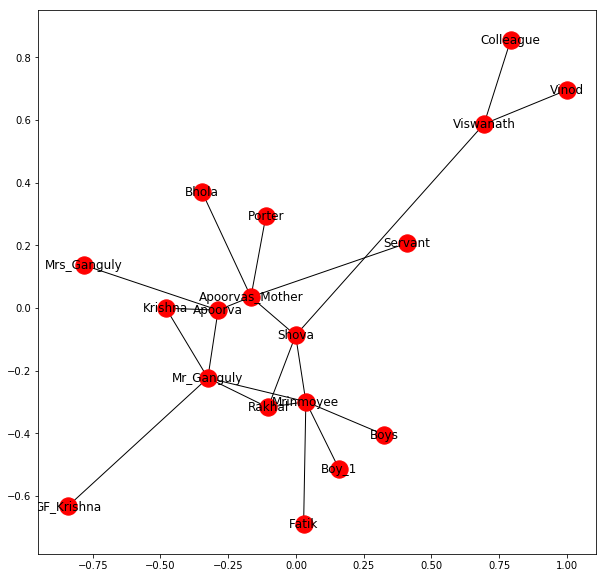

              Nodes  Degree       ECF       NCF
0         Mrinmoyee    70.0  0.299242  0.067292
1            Rakhal    27.0  0.231061  0.025956
2             Fatik     4.0  0.015152  0.002009
3             Boy_1     8.0  0.030303  0.004017
4              Boys     6.0  0.022727  0.003013
5             Shova    72.0  0.340909  0.118802
6        Mr_Ganguly    26.0  0.219697  0.038424
7   Apoorvas_Mother   141.0  0.534091  0.211411
8             Bhola     4.0  0.015152  0.004046
9            Porter     7.0  0.026515  0.007081
10          Servant     1.0  0.003788  0.001012
11          Apoorva   125.0  0.477273  0.164106
12       GF_Krishna     1.0  0.003788  0.000187
13          Krishna    15.0  0.117424  0.014527
14      Mrs_Ganguly     2.0  0.007576  0.001794
15            Vinod     4.0  0.015152  0.000287
16        Viswanath    10.0  0.037879  0.005811
17        Colleague     5.0  0.018939  0.000359
      Degree       ECF       NCF
0   0.321020  0.326703  0.220942
1   0.123822  0.252264

In [3]:
sm_1 = nx.read_weighted_edgelist('s_m_1.txt', delimiter=',')
print(nx.info(sm_1))

plt.figure(figsize = (10,10))
nx.draw_networkx(sm_1)
plt.show()

#Weighted Centralities
w_deg = sm_1.degree(weight='weight') # Degree
w_deg = list(w_deg)

total_edge_weight = total_weight_of_G(sm_1)  #ECF
w_ecf = weighted_ECF(sm_1, total_edge_weight)

total_edge_weight = total_weight_of_G(sm_1) #NCF
w_ncf = weighted_cness(sm_1,total_edge_weight)


df = pd.DataFrame()
df["Nodes"] = convert_to_list_value(w_deg,0)
df["Degree"] = convert_to_list_value(w_deg,1)
df["ECF"] = convert_to_list_value(w_ecf,1)
df["NCF"] = convert_to_list_value(w_ncf,1)

print(df)

degree_c = np.array(df['Degree'])
ecf_c = np.array(df['ECF'])
ncf_c = np.array(df['NCF'])

normalized_deg = preprocessing.normalize([degree_c])

normalized_ecf = preprocessing.normalize([ecf_c])

normalized_ncf = preprocessing.normalize([ncf_c])

df_2 = pd.DataFrame()
df_2["Degree"] = np.concatenate(normalized_deg).ravel()
df_2["ECF"] = np.concatenate(normalized_ecf).ravel()
df_2["NCF"] = np.concatenate(normalized_ncf).ravel()

print(df_2)

In [6]:
df_3 = df_2
df_3.round(decimals = 3)

,Degree,ECF,NCF
0,0.321,0.327,0.221
1,0.124,0.252,0.085
2,0.018,0.017,0.007
3,0.037,0.033,0.013
4,0.028,0.025,0.010
5,0.330,0.372,0.390
6,0.119,0.240,0.126
7,0.647,0.583,0.694
8,0.018,0.017,0.013
9,0.032,0.029,0.023


Text(0, 0.5, 'Values')

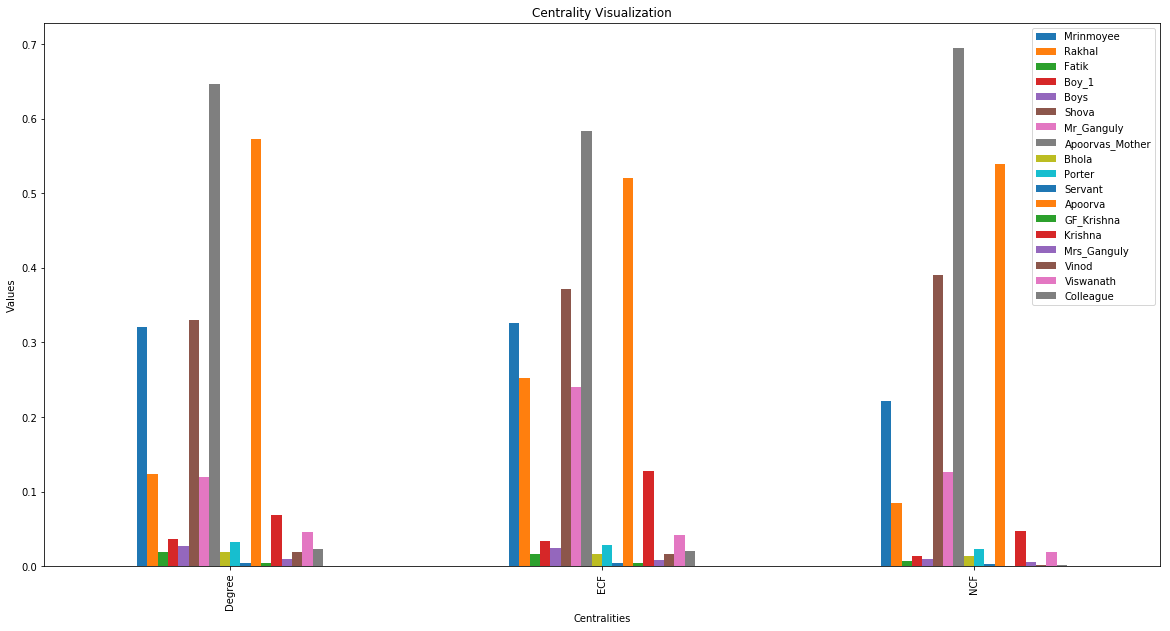

In [7]:
plotdata = pd.DataFrame({

    "Mrinmoyee":list(df_2.loc[0]),
    "Rakhal":list(df_2.loc[1]),
    "Fatik":list(df_2.loc[2]),

    "Boy_1":list(df_2.loc[3]),

    "Boys":list(df_2.loc[4]),
    "Shova":list(df_2.loc[5]),
    "Mr_Ganguly":list(df_2.loc[6]),
    "Apoorvas_Mother":list(df_2.loc[7]),
    
    "Bhola":list(df_2.loc[8]),
    
    "Porter":list(df_2.loc[9]),
    
    "Servant":list(df_2.loc[10]),
    "Apoorva":list(df_2.loc[11]),
    "GF_Krishna":list(df_2.loc[12]),
    "Krishna":list(df_2.loc[13]),
    "Mrs_Ganguly":list(df_2.loc[14]),
    "Vinod":list(df_2.loc[15]),
    "Viswanath":list(df_2.loc[16]),
    "Colleague":list(df_2.loc[17])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(20, 10))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

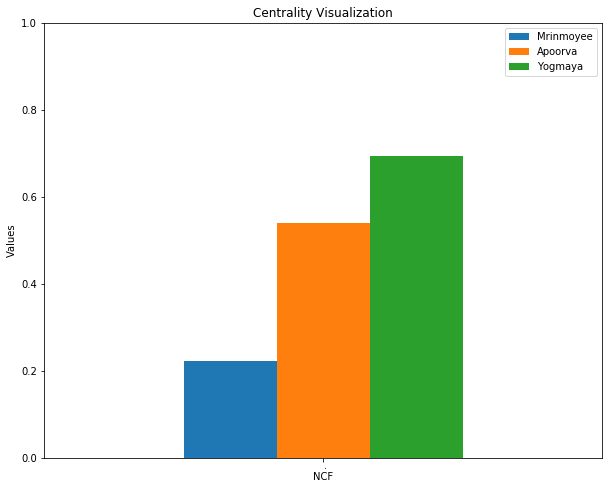

In [8]:
plotdata = pd.DataFrame({

    "Mrinmoyee":df_2.loc[0][2],
    "Apoorva":df_2.loc[11][2],
    "Yogmaya":df_2.loc[7][2]},

    index=["."])

plotdata.plot(kind="bar",figsize=(10, 8), ylim=[0,1])

plt.title("Centrality Visualization")

plt.xlabel("NCF")

plt.ylabel("Values")

### s_m_2

Name: 
Type: Graph
Number of nodes: 21
Number of edges: 29
Average degree:   2.7619


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


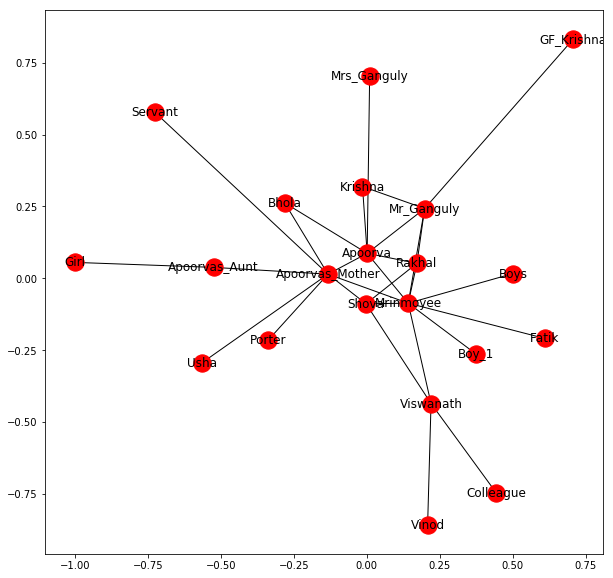

              Nodes  Degree       ECF       NCF
0         Mrinmoyee   140.0  0.844920  0.185664
1            Rakhal    38.0  0.342246  0.045912
2             Fatik     4.0  0.010695  0.002002
3             Boy_1     8.0  0.021390  0.004004
4              Boys     6.0  0.016043  0.003003
5             Shova    72.0  0.320856  0.085704
6        Mr_Ganguly    26.0  0.291444  0.027975
7   Apoorvas_Mother   178.0  0.676471  0.227787
8             Bhola     8.0  0.296791  0.007578
9            Porter     7.0  0.018717  0.004454
10          Servant     1.0  0.002674  0.000636
11          Apoorva   190.0  0.631016  0.245181
12       GF_Krishna     1.0  0.002674  0.000093
13          Krishna    15.0  0.082888  0.010724
14      Mrs_Ganguly     2.0  0.005348  0.001358
15            Vinod     4.0  0.010695  0.000357
16        Viswanath    25.0  0.149733  0.016979
17        Colleague     5.0  0.013369  0.000447
18             Usha     3.0  0.008021  0.001909
19    Apoorvas_Aunt    12.0  0.032086  0

In [10]:
sm_2 = nx.read_weighted_edgelist('s_m_2.txt', delimiter=',')
print(nx.info(sm_2))

plt.figure(figsize = (10,10))
nx.draw_networkx(sm_2)
plt.show()

#Weighted Centralities
w_deg = sm_2.degree(weight='weight') # Degree
w_deg = list(w_deg)

total_edge_weight = total_weight_of_G(sm_2)  #ECF
w_ecf = weighted_ECF(sm_2, total_edge_weight)

total_edge_weight = total_weight_of_G(sm_2) #NCF
w_ncf = weighted_cness(sm_2,total_edge_weight)


df = pd.DataFrame()
df["Nodes"] = convert_to_list_value(w_deg,0)
df["Degree"] = convert_to_list_value(w_deg,1)
df["ECF"] = convert_to_list_value(w_ecf,1)
df["NCF"] = convert_to_list_value(w_ncf,1)

print(df)

degree_c = np.array(df['Degree'])
ecf_c = np.array(df['ECF'])
ncf_c = np.array(df['NCF'])

normalized_deg = preprocessing.normalize([degree_c])

normalized_ecf = preprocessing.normalize([ecf_c])

normalized_ncf = preprocessing.normalize([ncf_c])

df_2 = pd.DataFrame()
df_2["Degree"] = np.concatenate(normalized_deg).ravel()
df_2["ECF"] = np.concatenate(normalized_ecf).ravel()
df_2["NCF"] = np.concatenate(normalized_ncf).ravel()

print(df_2)

In [11]:
df_3 = df_2
df_3.round(decimals = 3)

,Degree,ECF,NCF
0,0.452,0.598,0.468
1,0.123,0.242,0.116
2,0.013,0.008,0.005
3,0.026,0.015,0.010
4,0.019,0.011,0.008
5,0.232,0.227,0.216
6,0.084,0.206,0.071
7,0.575,0.479,0.574
8,0.026,0.210,0.019
9,0.023,0.013,0.011


Text(0, 0.5, 'Values')

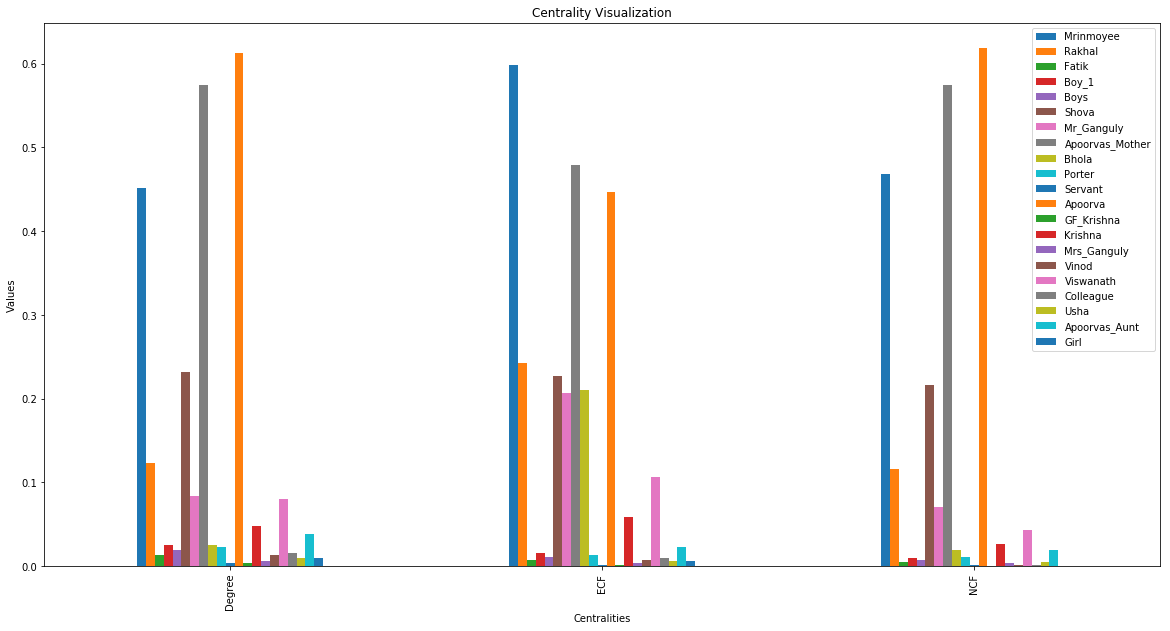

In [12]:
plotdata = pd.DataFrame({

    "Mrinmoyee":list(df_2.loc[0]),
    "Rakhal":list(df_2.loc[1]),
    "Fatik":list(df_2.loc[2]),

    "Boy_1":list(df_2.loc[3]),

    "Boys":list(df_2.loc[4]),
    "Shova":list(df_2.loc[5]),
    "Mr_Ganguly":list(df_2.loc[6]),
    "Apoorvas_Mother":list(df_2.loc[7]),
    
    "Bhola":list(df_2.loc[8]),
    
    "Porter":list(df_2.loc[9]),
    
    "Servant":list(df_2.loc[10]),
    "Apoorva":list(df_2.loc[11]),
    "GF_Krishna":list(df_2.loc[12]),
    "Krishna":list(df_2.loc[13]),
    "Mrs_Ganguly":list(df_2.loc[14]),
    "Vinod":list(df_2.loc[15]),
    "Viswanath":list(df_2.loc[16]),
    "Colleague":list(df_2.loc[17]),
    "Usha":list(df_2.loc[18]),
    "Apoorvas_Aunt":list(df_2.loc[19]),
    "Girl":list(df_2.loc[20])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(20, 10))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

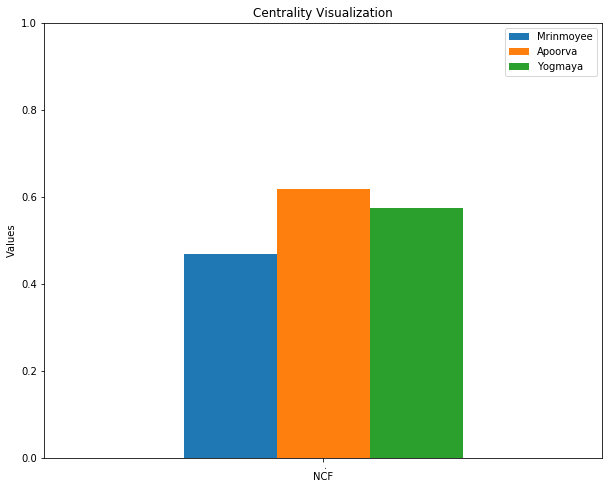

In [13]:
plotdata = pd.DataFrame({

    "Mrinmoyee":df_2.loc[0][2],
    "Apoorva":df_2.loc[11][2],
    "Yogmaya":df_2.loc[7][2]},

    index=["."])

plotdata.plot(kind="bar",figsize=(10, 8), ylim=[0,1])

plt.title("Centrality Visualization")

plt.xlabel("NCF")

plt.ylabel("Values")

### s_m_3

Name: 
Type: Graph
Number of nodes: 21
Number of edges: 30
Average degree:   2.8571


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


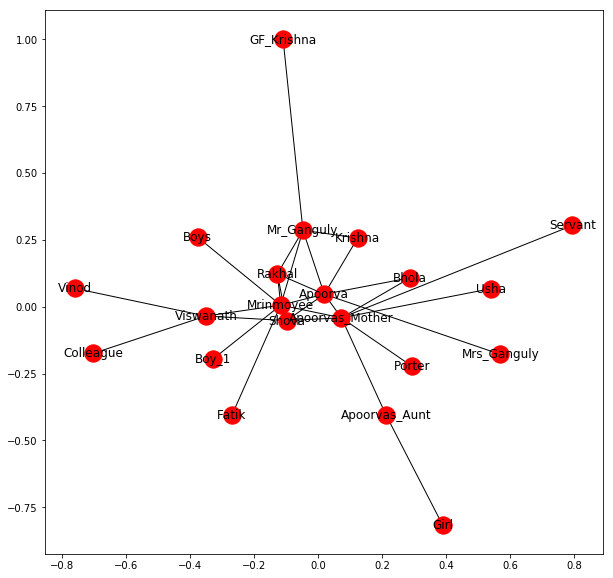

              Nodes  Degree       ECF       NCF
0         Mrinmoyee   259.0  0.891344  0.237172
1            Rakhal    57.0  0.460405  0.048910
2             Fatik     4.0  0.007366  0.001757
3             Boy_1     8.0  0.014733  0.003514
4              Boys     6.0  0.011050  0.002635
5             Shova   137.0  0.813996  0.124989
6        Mr_Ganguly    26.0  0.335175  0.019973
7   Apoorvas_Mother   209.0  0.712707  0.186779
8             Bhola     9.0  0.243094  0.005540
9            Porter     7.0  0.012891  0.002481
10          Servant     1.0  0.001842  0.000354
11          Apoorva   277.0  0.847145  0.249428
12       GF_Krishna     1.0  0.001842  0.000044
13          Krishna    15.0  0.057090  0.007300
14      Mrs_Ganguly     2.0  0.003683  0.000939
15            Vinod     4.0  0.007366  0.000278
16        Viswanath    41.0  0.198895  0.023500
17        Colleague     5.0  0.009208  0.000348
18             Usha     3.0  0.005525  0.001063
19    Apoorvas_Aunt    12.0  0.022099  0

In [14]:
sm_3 = nx.read_weighted_edgelist('s_m_3.txt', delimiter=',')
print(nx.info(sm_3))

plt.figure(figsize = (10,10))
nx.draw_networkx(sm_3)
plt.show()

#Weighted Centralities
w_deg = sm_3.degree(weight='weight') # Degree
w_deg = list(w_deg)

total_edge_weight = total_weight_of_G(sm_3)  #ECF
w_ecf = weighted_ECF(sm_3, total_edge_weight)

total_edge_weight = total_weight_of_G(sm_3) #NCF
w_ncf = weighted_cness(sm_3,total_edge_weight)


df = pd.DataFrame()
df["Nodes"] = convert_to_list_value(w_deg,0)
df["Degree"] = convert_to_list_value(w_deg,1)
df["ECF"] = convert_to_list_value(w_ecf,1)
df["NCF"] = convert_to_list_value(w_ncf,1)

print(df)

degree_c = np.array(df['Degree'])
ecf_c = np.array(df['ECF'])
ncf_c = np.array(df['NCF'])

normalized_deg = preprocessing.normalize([degree_c])

normalized_ecf = preprocessing.normalize([ecf_c])

normalized_ncf = preprocessing.normalize([ncf_c])

df_2 = pd.DataFrame()
df_2["Degree"] = np.concatenate(normalized_deg).ravel()
df_2["ECF"] = np.concatenate(normalized_ecf).ravel()
df_2["NCF"] = np.concatenate(normalized_ncf).ravel()

print(df_2)

In [15]:
df_3 = df_2
df_3.round(decimals = 3)

,Degree,ECF,NCF
0,0.562,0.505,0.571
1,0.124,0.261,0.118
2,0.009,0.004,0.004
3,0.017,0.008,0.008
4,0.013,0.006,0.006
5,0.297,0.462,0.301
6,0.056,0.190,0.048
7,0.453,0.404,0.450
8,0.020,0.138,0.013
9,0.015,0.007,0.006


Text(0, 0.5, 'Values')

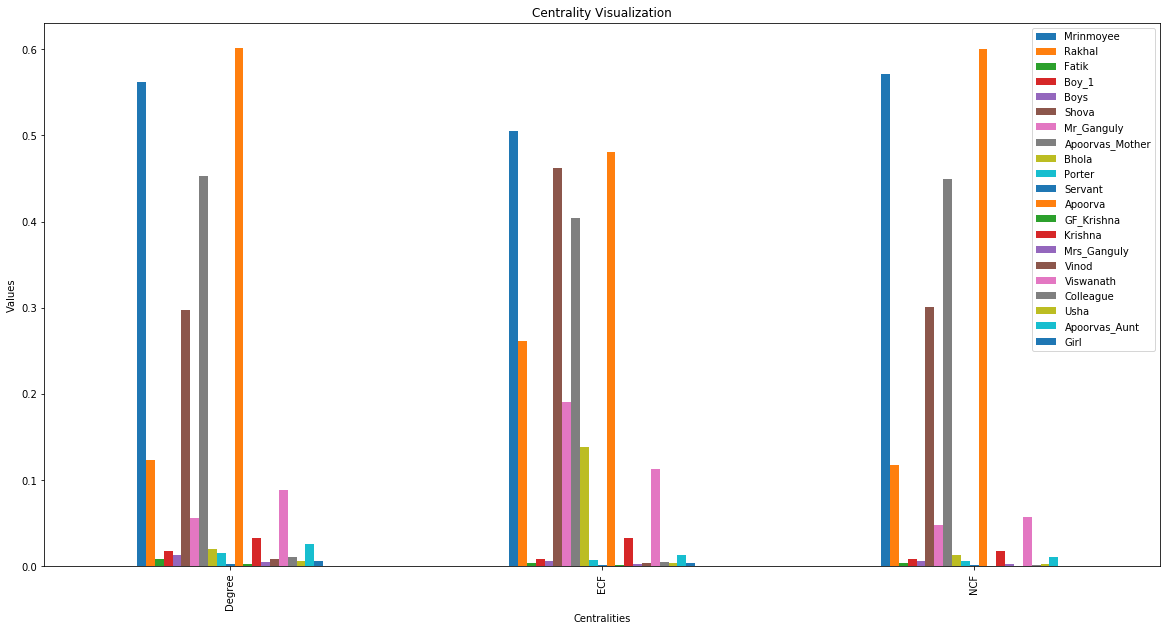

In [16]:
plotdata = pd.DataFrame({

    "Mrinmoyee":list(df_2.loc[0]),
    "Rakhal":list(df_2.loc[1]),
    "Fatik":list(df_2.loc[2]),

    "Boy_1":list(df_2.loc[3]),

    "Boys":list(df_2.loc[4]),
    "Shova":list(df_2.loc[5]),
    "Mr_Ganguly":list(df_2.loc[6]),
    "Apoorvas_Mother":list(df_2.loc[7]),
    
    "Bhola":list(df_2.loc[8]),
    
    "Porter":list(df_2.loc[9]),
    
    "Servant":list(df_2.loc[10]),
    "Apoorva":list(df_2.loc[11]),
    "GF_Krishna":list(df_2.loc[12]),
    "Krishna":list(df_2.loc[13]),
    "Mrs_Ganguly":list(df_2.loc[14]),
    "Vinod":list(df_2.loc[15]),
    "Viswanath":list(df_2.loc[16]),
    "Colleague":list(df_2.loc[17]),
    "Usha":list(df_2.loc[18]),
    "Apoorvas_Aunt":list(df_2.loc[19]),
    "Girl":list(df_2.loc[20])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(20, 10))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

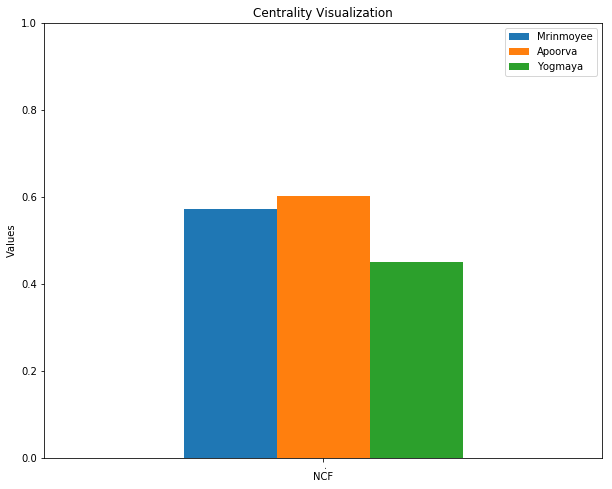

In [17]:
plotdata = pd.DataFrame({

    "Mrinmoyee":df_2.loc[0][2],
    "Apoorva":df_2.loc[11][2],
    "Yogmaya":df_2.loc[7][2]},

    index=["."])

plotdata.plot(kind="bar",figsize=(10, 8), ylim=[0,1])

plt.title("Centrality Visualization")

plt.xlabel("NCF")

plt.ylabel("Values")

### s_m_4

Name: 
Type: Graph
Number of nodes: 23
Number of edges: 35
Average degree:   3.0435


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


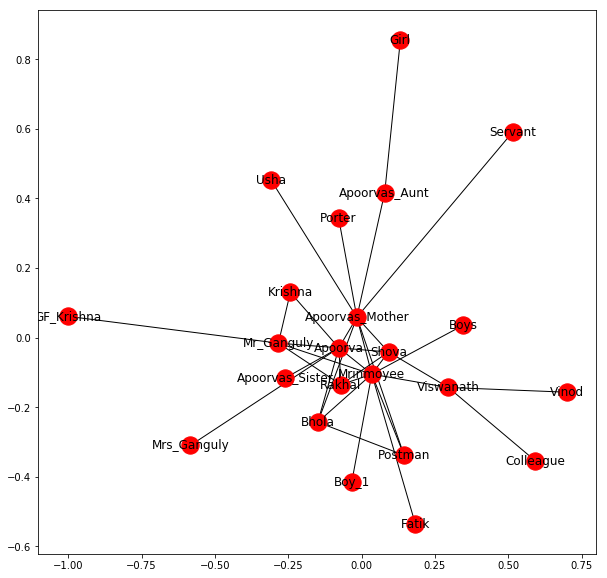

              Nodes  Degree       ECF       NCF
0         Mrinmoyee   295.0  0.890302  0.233381
1            Rakhal    57.0  0.429253  0.042501
2             Fatik     4.0  0.006359  0.001491
3             Boy_1     8.0  0.012719  0.002983
4              Boys     6.0  0.009539  0.002237
5             Shova   137.0  0.793323  0.107864
6        Mr_Ganguly    26.0  0.321145  0.017645
7   Apoorvas_Mother   247.0  0.721781  0.191349
8             Bhola    12.0  0.505564  0.008932
9            Porter     7.0  0.011129  0.002185
10          Servant     1.0  0.001590  0.000312
11          Apoorva   345.0  0.855326  0.269013
12       GF_Krishna     1.0  0.001590  0.000033
13          Krishna    15.0  0.049285  0.006730
14      Mrs_Ganguly     2.0  0.003180  0.000872
15            Vinod     4.0  0.006359  0.000207
16        Viswanath    41.0  0.171701  0.019379
17        Colleague     5.0  0.007949  0.000259
18             Usha     3.0  0.004769  0.000936
19    Apoorvas_Aunt    12.0  0.019078  0

In [18]:
sm_4 = nx.read_weighted_edgelist('s_m_4.txt', delimiter=',')
print(nx.info(sm_4))

plt.figure(figsize = (10,10))
nx.draw_networkx(sm_4)
plt.show()

#Weighted Centralities
w_deg = sm_4.degree(weight='weight') # Degree
w_deg = list(w_deg)

total_edge_weight = total_weight_of_G(sm_4)  #ECF
w_ecf = weighted_ECF(sm_4, total_edge_weight)

total_edge_weight = total_weight_of_G(sm_4) #NCF
w_ncf = weighted_cness(sm_4,total_edge_weight)


df = pd.DataFrame()
df["Nodes"] = convert_to_list_value(w_deg,0)
df["Degree"] = convert_to_list_value(w_deg,1)
df["ECF"] = convert_to_list_value(w_ecf,1)
df["NCF"] = convert_to_list_value(w_ncf,1)

print(df)

degree_c = np.array(df['Degree'])
ecf_c = np.array(df['ECF'])
ncf_c = np.array(df['NCF'])

normalized_deg = preprocessing.normalize([degree_c])

normalized_ecf = preprocessing.normalize([ecf_c])

normalized_ncf = preprocessing.normalize([ncf_c])

df_2 = pd.DataFrame()
df_2["Degree"] = np.concatenate(normalized_deg).ravel()
df_2["ECF"] = np.concatenate(normalized_ecf).ravel()
df_2["NCF"] = np.concatenate(normalized_ncf).ravel()

print(df_2)

In [19]:
df_3 = df_2
df_3.round(decimals = 3)

,Degree,ECF,NCF
0,0.545,0.493,0.553
1,0.105,0.238,0.101
2,0.007,0.004,0.004
3,0.015,0.007,0.007
4,0.011,0.005,0.005
5,0.253,0.440,0.256
6,0.048,0.178,0.042
7,0.457,0.400,0.454
8,0.022,0.280,0.021
9,0.013,0.006,0.005


Text(0, 0.5, 'Values')

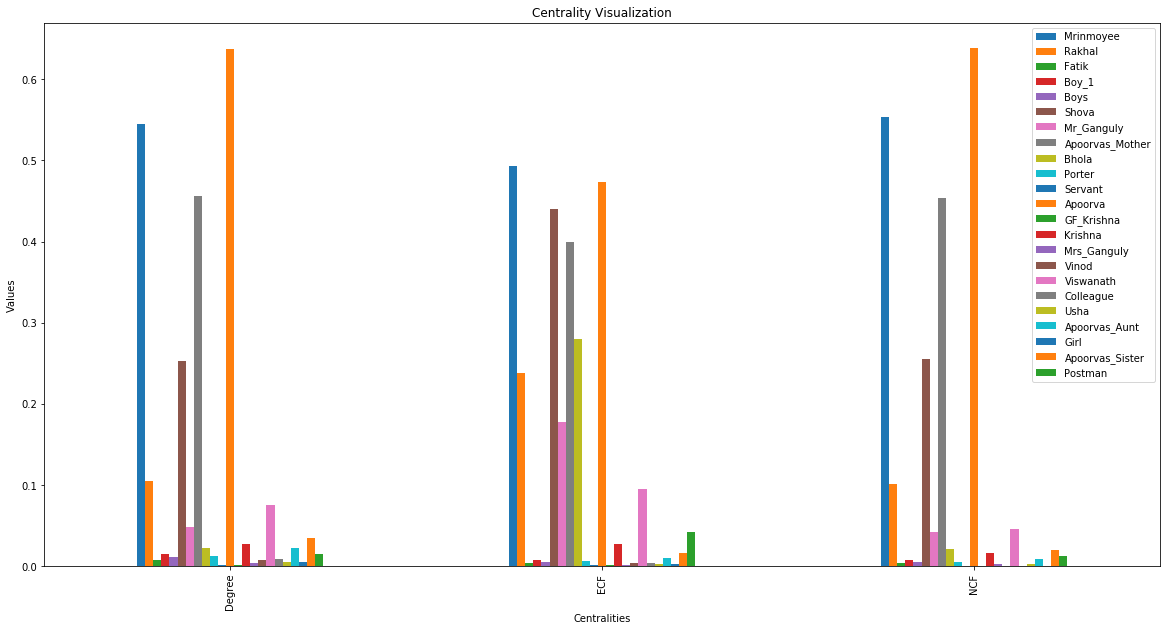

In [20]:
plotdata = pd.DataFrame({

    "Mrinmoyee":list(df_2.loc[0]),
    "Rakhal":list(df_2.loc[1]),
    "Fatik":list(df_2.loc[2]),

    "Boy_1":list(df_2.loc[3]),

    "Boys":list(df_2.loc[4]),
    "Shova":list(df_2.loc[5]),
    "Mr_Ganguly":list(df_2.loc[6]),
    "Apoorvas_Mother":list(df_2.loc[7]),
    
    "Bhola":list(df_2.loc[8]),
    
    "Porter":list(df_2.loc[9]),
    
    "Servant":list(df_2.loc[10]),
    "Apoorva":list(df_2.loc[11]),
    "GF_Krishna":list(df_2.loc[12]),
    "Krishna":list(df_2.loc[13]),
    "Mrs_Ganguly":list(df_2.loc[14]),
    "Vinod":list(df_2.loc[15]),
    "Viswanath":list(df_2.loc[16]),
    "Colleague":list(df_2.loc[17]),
    "Usha":list(df_2.loc[18]),
    "Apoorvas_Aunt":list(df_2.loc[19]),
    "Girl":list(df_2.loc[20]),
    "Apoorvas_Sister":list(df_2.loc[21]),
    "Postman":list(df_2.loc[22])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(20, 10))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

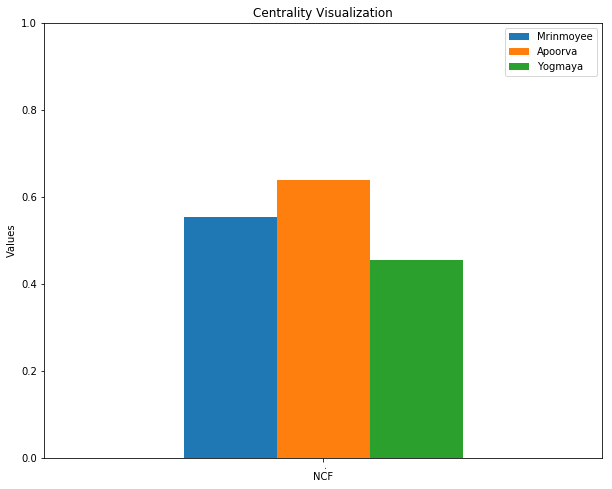

In [21]:
plotdata = pd.DataFrame({

    "Mrinmoyee":df_2.loc[0][2],
    "Apoorva":df_2.loc[11][2],
    "Yogmaya":df_2.loc[7][2]},

    index=["."])

plotdata.plot(kind="bar",figsize=(10, 8), ylim=[0,1])

plt.title("Centrality Visualization")

plt.xlabel("NCF")

plt.ylabel("Values")

In [22]:
# Let's create a Dataframe using lists
timestamp = ['t1', 't2', 't3', 't4']

apoorva = [0.538812,0.618223,0.600638,0.637918]

apoorvas_mother = [0.694131,0.574364,0.449775,0.453751]
mrinmoyee = [0.220942,0.468151,0.571126,0.553423]

# Now, create a pandas dataframe using above lists
df_pop_density = pd.DataFrame(
    {'Timestamp' : timestamp, 'Apoorva' : apoorva,'Apoorvas_Mother' : apoorvas_mother, 'Mrinmoyee' : mrinmoyee})

df_pop_density

,Timestamp,Apoorva,Apoorvas_Mother,Mrinmoyee
0,t1,0.538812,0.694131,0.220942
1,t2,0.618223,0.574364,0.468151
2,t3,0.600638,0.449775,0.571126
3,t4,0.637918,0.453751,0.553423


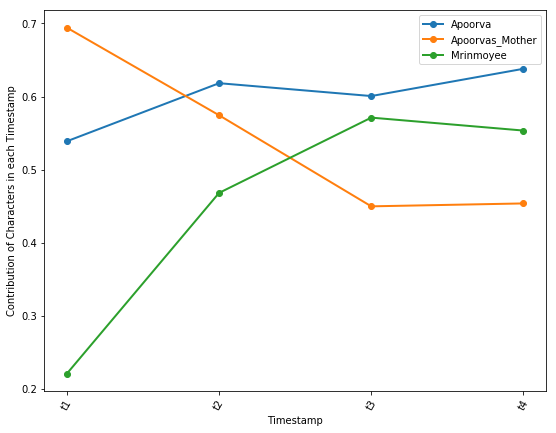

In [23]:
# Creating figure and axis objects using subplots()
fig, ax = plt.subplots(figsize=[9, 7])

ax.plot(df_pop_density['Timestamp'], df_pop_density['Apoorva'], marker='o', linewidth=2, label='Apoorva')
ax.plot(df_pop_density['Timestamp'], df_pop_density['Apoorvas_Mother'], marker='o', linewidth=2, label='Apoorvas_Mother')
ax.plot(df_pop_density['Timestamp'], df_pop_density['Mrinmoyee'], marker='o', linewidth=2, label='Mrinmoyee')
plt.xticks(rotation=60)
ax.set_xlabel('Timestamp')
ax.set_ylabel('Contribution of Characters in each Timestamp')
plt.legend()
plt.show()

In [ ]:
# Reevaluate to calculate the correlation

In [42]:
# Let's create a Dataframe using lists
timestamp = ['t1', 't2', 't3', 't4']

apoorva_mother = [0.49072340425531913,0.5302779420461265,0.7639265541602611,0.7505486123335093]

apoorva_mrinmoyee = [0,0.48571428571428565,0.809584210306232,0.7797592729059198]

# Now, create a pandas dataframe using above lists
df_pop_density = pd.DataFrame(
    {'Timestamp' : timestamp, 'Correlation_With_Mother' : apoorva_mother, 'Correlation_With_Mrinmoyee' : apoorva_mrinmoyee})

df_pop_density

,Timestamp,Correlation_With_Mother,Correlation_With_Mrinmoyee
0,t1,0.490723,0.000000
1,t2,0.530278,0.485714
2,t3,0.763927,0.809584
3,t4,0.750549,0.779759


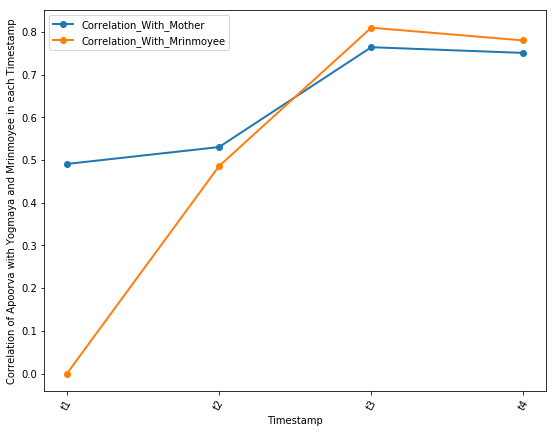

In [43]:
# Creating figure and axis objects using subplots()
fig, ax = plt.subplots(figsize=[9, 7])

ax.plot(df_pop_density['Timestamp'], df_pop_density['Correlation_With_Mother'], marker='o', linewidth=2, label='Correlation_With_Mother')
ax.plot(df_pop_density['Timestamp'], df_pop_density['Correlation_With_Mrinmoyee'], marker='o', linewidth=2, label='Correlation_With_Mrinmoyee')
plt.xticks(rotation=60)
ax.set_xlabel('Timestamp')
ax.set_ylabel('Correlation of Apoorva with Yogmaya and Mrinmoyee in each Timestamp')
plt.legend()
plt.show()

In [45]:
def intersection(lst1, lst2):
    lst3 = [value for value in lst1 if value in lst2]
    return lst3

def correlation(G,i,j):
    d_i = G.degree(i, weight='weight')
    d_j = G.degree(j, weight='weight')
    w_ic = 0
    w_jc = 0
    w_ = G.get_edge_data(i, j)
    if(w_ == None):
        w_ij = 0
    else:
        w_ij = w_['weight']
    common_nbr = intersection(list(G.neighbors(i)),list(G.neighbors(j)))
    if(w_ij == 0):
        print("The correlation is 0.")
    elif((w_ij != 0) and (len(common_nbr) == 0)):
        corr = ((w_ij + w_ic) / d_i) * ((w_ij + w_jc) / d_j)
        return corr
    else:
        for k in range(len(common_nbr)):
            w_i = G.get_edge_data(i, common_nbr[k])
            val = w_i['weight']
            w_ic = w_ic + val
        
        for l in range(len(common_nbr)):
            w_j = G.get_edge_data(j, common_nbr[l])
            val = w_j['weight']
            w_jc = w_jc + val
        
        corr = ((w_ij + w_ic) / d_i) * ((w_ij + w_jc) / d_j)
        return corr

def correlation_of_nodes(GG, nodes, i):
    nn_c = []
    for n in range(0,len(nodes)):
        nn_c.append(i)
        nn_c.append(nodes[n])
        j = nodes[n]
        corr = correlation(GG,i,j)
        nn_c.append(corr)
        print(nn_c)
        nn_c = []

In [46]:
node_1 = list(sm_1.nodes())
correlation_of_nodes(sm_1, node_1, 'Mrinmoyee')

The correlation is 0.
['Mrinmoyee', 'Mrinmoyee', None]
['Mrinmoyee', 'Rakhal', 0.7428571428571429]
['Mrinmoyee', 'Fatik', 0.05714285714285714]
['Mrinmoyee', 'Boy_1', 0.11428571428571428]
['Mrinmoyee', 'Boys', 0.08571428571428572]
['Mrinmoyee', 'Shova', 0.34027777777777773]
['Mrinmoyee', 'Mr_Ganguly', 0.09230769230769231]
The correlation is 0.
['Mrinmoyee', 'Apoorvas_Mother', None]
The correlation is 0.
['Mrinmoyee', 'Bhola', None]
The correlation is 0.
['Mrinmoyee', 'Porter', None]
The correlation is 0.
['Mrinmoyee', 'Servant', None]
The correlation is 0.
['Mrinmoyee', 'Apoorva', None]
The correlation is 0.
['Mrinmoyee', 'GF_Krishna', None]
The correlation is 0.
['Mrinmoyee', 'Krishna', None]
The correlation is 0.
['Mrinmoyee', 'Mrs_Ganguly', None]
The correlation is 0.
['Mrinmoyee', 'Vinod', None]
The correlation is 0.
['Mrinmoyee', 'Viswanath', None]
The correlation is 0.
['Mrinmoyee', 'Colleague', None]


In [47]:
node_1 = list(sm_1.nodes())
correlation_of_nodes(sm_1, node_1, 'Apoorva')

The correlation is 0.
['Apoorva', 'Mrinmoyee', None]
The correlation is 0.
['Apoorva', 'Rakhal', None]
The correlation is 0.
['Apoorva', 'Fatik', None]
The correlation is 0.
['Apoorva', 'Boy_1', None]
The correlation is 0.
['Apoorva', 'Boys', None]
The correlation is 0.
['Apoorva', 'Shova', None]
['Apoorva', 'Mr_Ganguly', 0.15692307692307692]
['Apoorva', 'Apoorvas_Mother', 0.49072340425531913]
The correlation is 0.
['Apoorva', 'Bhola', None]
The correlation is 0.
['Apoorva', 'Porter', None]
The correlation is 0.
['Apoorva', 'Servant', None]
The correlation is 0.
['Apoorva', 'Apoorva', None]
The correlation is 0.
['Apoorva', 'GF_Krishna', None]
['Apoorva', 'Krishna', 0.24]
['Apoorva', 'Mrs_Ganguly', 0.016]
The correlation is 0.
['Apoorva', 'Vinod', None]
The correlation is 0.
['Apoorva', 'Viswanath', None]
The correlation is 0.
['Apoorva', 'Colleague', None]


In [ ]:
['Mrinmoyee', 'Rakhal', 0.7428571428571429]
['Mrinmoyee', 'Fatik', 0.05714285714285714]
['Mrinmoyee', 'Boy_1', 0.11428571428571428]
['Mrinmoyee', 'Boys', 0.08571428571428572]
['Mrinmoyee', 'Shova', 0.34027777777777773]
['Mrinmoyee', 'Mr_Ganguly', 0.09230769230769231]

['Apoorva', 'Mr_Ganguly', 0.15692307692307692]
['Apoorva', 'Apoorvas_Mother', 0.49072340425531913]
['Apoorva', 'Krishna', 0.24]
['Apoorva', 'Mrs_Ganguly', 0.016]

In [48]:
node_2 = list(sm_2.nodes())
correlation_of_nodes(sm_2, node_2, 'Mrinmoyee')

The correlation is 0.
['Mrinmoyee', 'Mrinmoyee', None]
['Mrinmoyee', 'Rakhal', 0.6571428571428571]
['Mrinmoyee', 'Fatik', 0.02857142857142857]
['Mrinmoyee', 'Boy_1', 0.05714285714285714]
['Mrinmoyee', 'Boys', 0.04285714285714286]
['Mrinmoyee', 'Shova', 0.5642857142857143]
['Mrinmoyee', 'Mr_Ganguly', 0.4021978021978022]
['Mrinmoyee', 'Apoorvas_Mother', 0.5314606741573034]
The correlation is 0.
['Mrinmoyee', 'Bhola', None]
The correlation is 0.
['Mrinmoyee', 'Porter', None]
The correlation is 0.
['Mrinmoyee', 'Servant', None]
['Mrinmoyee', 'Apoorva', 0.48571428571428565]
The correlation is 0.
['Mrinmoyee', 'GF_Krishna', None]
The correlation is 0.
['Mrinmoyee', 'Krishna', None]
The correlation is 0.
['Mrinmoyee', 'Mrs_Ganguly', None]
The correlation is 0.
['Mrinmoyee', 'Vinod', None]
['Mrinmoyee', 'Viswanath', 0.2102857142857143]
The correlation is 0.
['Mrinmoyee', 'Colleague', None]
The correlation is 0.
['Mrinmoyee', 'Usha', None]
The correlation is 0.
['Mrinmoyee', 'Apoorvas_Aunt', No

In [49]:
node_2 = list(sm_2.nodes())
correlation_of_nodes(sm_2, node_2, 'Apoorva')

['Apoorva', 'Mrinmoyee', 0.48571428571428565]
['Apoorva', 'Rakhal', 0.3155124653739612]
The correlation is 0.
['Apoorva', 'Fatik', None]
The correlation is 0.
['Apoorva', 'Boy_1', None]
The correlation is 0.
['Apoorva', 'Boys', None]
The correlation is 0.
['Apoorva', 'Shova', None]
['Apoorva', 'Mr_Ganguly', 0.409919028340081]
['Apoorva', 'Apoorvas_Mother', 0.5302779420461265]
['Apoorva', 'Bhola', 0.5631578947368421]
The correlation is 0.
['Apoorva', 'Porter', None]
The correlation is 0.
['Apoorva', 'Servant', None]
The correlation is 0.
['Apoorva', 'Apoorva', None]
The correlation is 0.
['Apoorva', 'GF_Krishna', None]
['Apoorva', 'Krishna', 0.15789473684210525]
['Apoorva', 'Mrs_Ganguly', 0.010526315789473684]
The correlation is 0.
['Apoorva', 'Vinod', None]
The correlation is 0.
['Apoorva', 'Viswanath', None]
The correlation is 0.
['Apoorva', 'Colleague', None]
The correlation is 0.
['Apoorva', 'Usha', None]
The correlation is 0.
['Apoorva', 'Apoorvas_Aunt', None]
The correlation is 0.

In [ ]:
['Mrinmoyee', 'Rakhal', 0.6571428571428571]
['Mrinmoyee', 'Fatik', 0.02857142857142857]
['Mrinmoyee', 'Boy_1', 0.05714285714285714]
['Mrinmoyee', 'Boys', 0.04285714285714286]
['Mrinmoyee', 'Shova', 0.5642857142857143]
['Mrinmoyee', 'Mr_Ganguly', 0.4021978021978022]
['Mrinmoyee', 'Apoorvas_Mother', 0.5314606741573034]
['Mrinmoyee', 'Apoorva', 0.48571428571428565]
['Mrinmoyee', 'Viswanath', 0.2102857142857143]


['Apoorva', 'Mrinmoyee', 0.48571428571428565]
['Apoorva', 'Rakhal', 0.3155124653739612]
['Apoorva', 'Mr_Ganguly', 0.409919028340081]
['Apoorva', 'Apoorvas_Mother', 0.5302779420461265]
['Apoorva', 'Bhola', 0.5631578947368421]
['Apoorva', 'Krishna', 0.15789473684210525]
['Apoorva', 'Mrs_Ganguly', 0.010526315789473684]

In [50]:
node_3 = list(sm_3.nodes())
correlation_of_nodes(sm_3, node_3, 'Mrinmoyee')

The correlation is 0.
['Mrinmoyee', 'Mrinmoyee', None]
['Mrinmoyee', 'Rakhal', 0.7760617760617761]
['Mrinmoyee', 'Fatik', 0.015444015444015444]
['Mrinmoyee', 'Boy_1', 0.03088803088803089]
['Mrinmoyee', 'Boys', 0.023166023166023165]
['Mrinmoyee', 'Shova', 0.918918918918919]
['Mrinmoyee', 'Mr_Ganguly', 0.4775764775764776]
['Mrinmoyee', 'Apoorvas_Mother', 0.6322440006650534]
The correlation is 0.
['Mrinmoyee', 'Bhola', None]
The correlation is 0.
['Mrinmoyee', 'Porter', None]
The correlation is 0.
['Mrinmoyee', 'Servant', None]
['Mrinmoyee', 'Apoorva', 0.809584210306232]
The correlation is 0.
['Mrinmoyee', 'GF_Krishna', None]
The correlation is 0.
['Mrinmoyee', 'Krishna', None]
The correlation is 0.
['Mrinmoyee', 'Mrs_Ganguly', None]
The correlation is 0.
['Mrinmoyee', 'Vinod', None]
['Mrinmoyee', 'Viswanath', 0.24710424710424708]
The correlation is 0.
['Mrinmoyee', 'Colleague', None]
The correlation is 0.
['Mrinmoyee', 'Usha', None]
The correlation is 0.
['Mrinmoyee', 'Apoorvas_Aunt', No

In [51]:
node_3 = list(sm_3.nodes())
correlation_of_nodes(sm_3, node_3, 'Apoorva')

['Apoorva', 'Mrinmoyee', 0.809584210306232]
['Apoorva', 'Rakhal', 0.48375451263537905]
The correlation is 0.
['Apoorva', 'Fatik', None]
The correlation is 0.
['Apoorva', 'Boy_1', None]
The correlation is 0.
['Apoorva', 'Boys', None]
['Apoorva', 'Shova', 0.7620754170070358]
['Apoorva', 'Mr_Ganguly', 0.468619827825604]
['Apoorva', 'Apoorvas_Mother', 0.7639265541602611]
['Apoorva', 'Bhola', 0.4584837545126354]
The correlation is 0.
['Apoorva', 'Porter', None]
The correlation is 0.
['Apoorva', 'Servant', None]
The correlation is 0.
['Apoorva', 'Apoorva', None]
The correlation is 0.
['Apoorva', 'GF_Krishna', None]
['Apoorva', 'Krishna', 0.10830324909747292]
['Apoorva', 'Mrs_Ganguly', 0.007220216606498195]
The correlation is 0.
['Apoorva', 'Vinod', None]
The correlation is 0.
['Apoorva', 'Viswanath', None]
The correlation is 0.
['Apoorva', 'Colleague', None]
The correlation is 0.
['Apoorva', 'Usha', None]
The correlation is 0.
['Apoorva', 'Apoorvas_Aunt', None]
The correlation is 0.
['Apoorv

In [ ]:
['Mrinmoyee', 'Rakhal', 0.7760617760617761]
['Mrinmoyee', 'Fatik', 0.015444015444015444]
['Mrinmoyee', 'Boy_1', 0.03088803088803089]
['Mrinmoyee', 'Boys', 0.023166023166023165]
['Mrinmoyee', 'Shova', 0.918918918918919]
['Mrinmoyee', 'Mr_Ganguly', 0.4775764775764776]
['Mrinmoyee', 'Apoorvas_Mother', 0.6322440006650534]
['Mrinmoyee', 'Apoorva', 0.809584210306232]
['Mrinmoyee', 'Viswanath', 0.24710424710424708]


['Apoorva', 'Mrinmoyee', 0.809584210306232]
['Apoorva', 'Rakhal', 0.48375451263537905]
['Apoorva', 'Shova', 0.7620754170070358]
['Apoorva', 'Mr_Ganguly', 0.468619827825604]
['Apoorva', 'Apoorvas_Mother', 0.7639265541602611]
['Apoorva', 'Bhola', 0.4584837545126354]
['Apoorva', 'Krishna', 0.10830324909747292]
['Apoorva', 'Mrs_Ganguly', 0.007220216606498195]

In [52]:
node_4 = list(sm_4.nodes())
correlation_of_nodes(sm_4, node_4, 'Mrinmoyee')

The correlation is 0.
['Mrinmoyee', 'Mrinmoyee', None]
['Mrinmoyee', 'Rakhal', 0.7491525423728813]
['Mrinmoyee', 'Fatik', 0.013559322033898305]
['Mrinmoyee', 'Boy_1', 0.02711864406779661]
['Mrinmoyee', 'Boys', 0.020338983050847456]
['Mrinmoyee', 'Shova', 0.9016949152542373]
['Mrinmoyee', 'Mr_Ganguly', 0.48187744458930903]
['Mrinmoyee', 'Apoorvas_Mother', 0.6916077677897482]
['Mrinmoyee', 'Bhola', 0.5254237288135594]
The correlation is 0.
['Mrinmoyee', 'Porter', None]
The correlation is 0.
['Mrinmoyee', 'Servant', None]
['Mrinmoyee', 'Apoorva', 0.7797592729059198]
The correlation is 0.
['Mrinmoyee', 'GF_Krishna', None]
The correlation is 0.
['Mrinmoyee', 'Krishna', None]
The correlation is 0.
['Mrinmoyee', 'Mrs_Ganguly', None]
The correlation is 0.
['Mrinmoyee', 'Vinod', None]
['Mrinmoyee', 'Viswanath', 0.2169491525423729]
The correlation is 0.
['Mrinmoyee', 'Colleague', None]
The correlation is 0.
['Mrinmoyee', 'Usha', None]
The correlation is 0.
['Mrinmoyee', 'Apoorvas_Aunt', None]
Th

In [53]:
node_4 = list(sm_4.nodes())
correlation_of_nodes(sm_4, node_4, 'Apoorva')

['Apoorva', 'Mrinmoyee', 0.7797592729059198]
['Apoorva', 'Rakhal', 0.4463768115942029]
The correlation is 0.
['Apoorva', 'Fatik', None]
The correlation is 0.
['Apoorva', 'Boy_1', None]
The correlation is 0.
['Apoorva', 'Boys', None]
['Apoorva', 'Shova', 0.7362741986670898]
['Apoorva', 'Mr_Ganguly', 0.4319955406911929]
['Apoorva', 'Apoorvas_Mother', 0.7505486123335093]
['Apoorva', 'Bhola', 0.717391304347826]
The correlation is 0.
['Apoorva', 'Porter', None]
The correlation is 0.
['Apoorva', 'Servant', None]
The correlation is 0.
['Apoorva', 'Apoorva', None]
The correlation is 0.
['Apoorva', 'GF_Krishna', None]
['Apoorva', 'Krishna', 0.08695652173913043]
['Apoorva', 'Mrs_Ganguly', 0.005797101449275362]
The correlation is 0.
['Apoorva', 'Vinod', None]
The correlation is 0.
['Apoorva', 'Viswanath', None]
The correlation is 0.
['Apoorva', 'Colleague', None]
The correlation is 0.
['Apoorva', 'Usha', None]
The correlation is 0.
['Apoorva', 'Apoorvas_Aunt', None]
The correlation is 0.
['Apoorv

In [ ]:
['Mrinmoyee', 'Rakhal', 0.7491525423728813]
['Mrinmoyee', 'Fatik', 0.013559322033898305]
['Mrinmoyee', 'Boy_1', 0.02711864406779661]
['Mrinmoyee', 'Boys', 0.020338983050847456]
['Mrinmoyee', 'Shova', 0.9016949152542373]
['Mrinmoyee', 'Mr_Ganguly', 0.48187744458930903]
['Mrinmoyee', 'Apoorvas_Mother', 0.6916077677897482]
['Mrinmoyee', 'Bhola', 0.5254237288135594]
['Mrinmoyee', 'Apoorva', 0.7797592729059198]
['Mrinmoyee', 'Viswanath', 0.2169491525423729]
['Mrinmoyee', 'Postman', 0.13898305084745763]


['Apoorva', 'Mrinmoyee', 0.7797592729059198]
['Apoorva', 'Rakhal', 0.4463768115942029]
['Apoorva', 'Shova', 0.7362741986670898]
['Apoorva', 'Mr_Ganguly', 0.4319955406911929]
['Apoorva', 'Apoorvas_Mother', 0.7505486123335093]
['Apoorva', 'Bhola', 0.717391304347826]
['Apoorva', 'Krishna', 0.08695652173913043]
['Apoorva', 'Mrs_Ganguly', 0.005797101449275362]
['Apoorva', 'Apoorvas_Sister', 0.05507246376811594]

In [55]:
def correlation_of_nodes(G, nodes, i, W):
    nn_c = []
    for n in range(0,len(nodes)):
        nn_c.append(i)
        nn_c.append(nodes[n])
        j = nodes[n]
        w_ij = G.get_edge_data(i, j)
        if(w_ij == None):
            val = 0
        else:
            val = w_ij['weight']
        corr = val/W
        nn_c.append(corr)
        print('\n')
        print(nn_c)
        nn_c = []

In [ ]:
['Mrinmoyee', 'Rakhal', 0.06818181818181818]
['Mrinmoyee', 'Fatik', 0.015151515151515152]
['Mrinmoyee', 'Boy_1', 0.030303030303030304]
['Mrinmoyee', 'Boys', 0.022727272727272728]
['Mrinmoyee', 'Shova', 0.11742424242424243]
['Mrinmoyee', 'Mr_Ganguly', 0.011363636363636364]

['Apoorva', 'Mr_Ganguly', 0.06060606060606061]
['Apoorva', 'Apoorvas_Mother', 0.3522727272727273]
['Apoorva', 'Krishna', 0.05303030303030303]
['Apoorva', 'Mrs_Ganguly', 0.007575757575757576]

In [ ]:
['Mrinmoyee', 'Rakhal', 0.0481283422459893]
['Mrinmoyee', 'Fatik', 0.0106951871657754]
['Mrinmoyee', 'Boy_1', 0.0213903743315508]
['Mrinmoyee', 'Boys', 0.016042780748663103]
['Mrinmoyee', 'Shova', 0.08288770053475936]
['Mrinmoyee', 'Mr_Ganguly', 0.008021390374331552]
['Mrinmoyee', 'Apoorvas_Mother', 0.040106951871657755]
['Mrinmoyee', 'Apoorva', 0.10695187165775401]
['Mrinmoyee', 'Viswanath', 0.040106951871657755]


['Apoorva', 'Mrinmoyee', 0.10695187165775401]
['Apoorva', 'Rakhal', 0.029411764705882353]
['Apoorva', 'Mr_Ganguly', 0.0427807486631016]
['Apoorva', 'Apoorvas_Mother', 0.27540106951871657]
['Apoorva', 'Bhola', 0.0106951871657754]
['Apoorva', 'Krishna', 0.0374331550802139]
['Apoorva', 'Mrs_Ganguly', 0.0053475935828877]

In [ ]:
['Mrinmoyee', 'Rakhal', 0.06813996316758748]
['Mrinmoyee', 'Fatik', 0.007366482504604052]
['Mrinmoyee', 'Boy_1', 0.014732965009208104]
['Mrinmoyee', 'Boys', 0.011049723756906077]
['Mrinmoyee', 'Shova', 0.12338858195211787]
['Mrinmoyee', 'Mr_Ganguly', 0.0055248618784530384]
['Mrinmoyee', 'Apoorvas_Mother', 0.04604051565377532]
['Mrinmoyee', 'Apoorva', 0.1731123388581952]
['Mrinmoyee', 'Viswanath', 0.027624309392265192]


['Apoorva', 'Mrinmoyee', 0.1731123388581952]
['Apoorva', 'Rakhal', 0.020257826887661142]
['Apoorva', 'Shova', 0.02394106813996317]
['Apoorva', 'Mr_Ganguly', 0.029465930018416207]
['Apoorva', 'Apoorvas_Mother', 0.2265193370165746]
['Apoorva', 'Bhola', 0.007366482504604052]
['Apoorva', 'Krishna', 0.02578268876611418]
['Apoorva', 'Mrs_Ganguly', 0.003683241252302026]

In [68]:
total_weight_of_G(sm_4)

629.0

In [70]:
node = list(sm_4.nodes())
correlation_of_nodes(sm_4, node, 'Mrinmoyee', 629)



['Mrinmoyee', 'Mrinmoyee', 0.0]


['Mrinmoyee', 'Rakhal', 0.058823529411764705]


['Mrinmoyee', 'Fatik', 0.006359300476947536]


['Mrinmoyee', 'Boy_1', 0.012718600953895072]


['Mrinmoyee', 'Boys', 0.009538950715421303]


['Mrinmoyee', 'Shova', 0.10651828298887123]


['Mrinmoyee', 'Mr_Ganguly', 0.0047694753577106515]


['Mrinmoyee', 'Apoorvas_Mother', 0.05246422893481717]


['Mrinmoyee', 'Bhola', 0.003179650238473768]


['Mrinmoyee', 'Porter', 0.0]


['Mrinmoyee', 'Servant', 0.0]


['Mrinmoyee', 'Apoorva', 0.18124006359300476]


['Mrinmoyee', 'GF_Krishna', 0.0]


['Mrinmoyee', 'Krishna', 0.0]


['Mrinmoyee', 'Mrs_Ganguly', 0.0]


['Mrinmoyee', 'Vinod', 0.0]


['Mrinmoyee', 'Viswanath', 0.02384737678855326]


['Mrinmoyee', 'Colleague', 0.0]


['Mrinmoyee', 'Usha', 0.0]


['Mrinmoyee', 'Apoorvas_Aunt', 0.0]


['Mrinmoyee', 'Girl', 0.0]


['Mrinmoyee', 'Apoorvas_Sister', 0.0]


['Mrinmoyee', 'Postman', 0.009538950715421303]


In [ ]:
['Mrinmoyee', 'Rakhal', 0.058823529411764705]
['Mrinmoyee', 'Fatik', 0.006359300476947536]
['Mrinmoyee', 'Boy_1', 0.012718600953895072]
['Mrinmoyee', 'Boys', 0.009538950715421303]
['Mrinmoyee', 'Shova', 0.10651828298887123]
['Mrinmoyee', 'Mr_Ganguly', 0.0047694753577106515]
['Mrinmoyee', 'Apoorvas_Mother', 0.05246422893481717]
['Mrinmoyee', 'Bhola', 0.003179650238473768]
['Mrinmoyee', 'Apoorva', 0.18124006359300476]
['Mrinmoyee', 'Viswanath', 0.02384737678855326]
['Mrinmoyee', 'Postman', 0.009538950715421303]



['Apoorva', 'Mrinmoyee', 0.18124006359300476]
['Apoorva', 'Rakhal', 0.017488076311605722]
['Apoorva', 'Shova', 0.02066772655007949]
['Apoorva', 'Mr_Ganguly', 0.025437201907790145]
['Apoorva', 'Apoorvas_Mother', 0.24165341812400637]
['Apoorva', 'Bhola', 0.006359300476947536]
['Apoorva', 'Krishna', 0.022257551669316374]
['Apoorva', 'Mrs_Ganguly', 0.003179650238473768]
['Apoorva', 'Apoorvas_Sister', 0.030206677265500796]
